<a href="https://colab.research.google.com/github/vyakhyaagoyal/aiml_colab_sem-4/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [ ]:
df=pd.read_csv('/content/housing_lr_lab_200.csv - housing_lr_lab_200.csv.csv')

In [ ]:
df.info

<bound method DataFrame.info of        id  area_sqft  bedrooms  age_years  distance_km  school_rating  \
0    H001        662         1          6          NaN            9.3   
1    H002       1511         3          0          9.7            7.1   
2    H003       2807         6          7          0.8            NaN   
3    H004       2122         4          5          6.1            8.9   
4    H005        673         1          3          NaN            8.5   
..    ...        ...       ...        ...          ...            ...   
195  H196       1959         3          3         11.9            8.1   
196  H197        967         2          4         11.4            8.5   
197  H198        647         1          8          6.9            7.3   
198  H199       2315         5          9         10.4            7.4   
199  H200       1367         2          7          NaN            7.5   

     price_lakh  
0         109.6  
1         132.1  
2         253.0  
3         185.8  
4          89.8  
..          ...  
195       155.6  
196       112.4  
197        84.6  
198       187.1  
199       135.6  

[200 rows x 7 columns]>

In [ ]:
df.isnull().sum()

,0
id,0
area_sqft,0
bedrooms,0
age_years,0
distance_km,20
school_rating,20
price_lakh,0


In [ ]:
df["distance_km"] = df["distance_km"].fillna(df["distance_km"].median())
df["school_rating"] = df["school_rating"].fillna(df["school_rating"].median())

In [ ]:
df.isnull().sum()

,0
id,0
area_sqft,0
bedrooms,0
age_years,0
distance_km,0
school_rating,0
price_lakh,0


In [ ]:
df

,id,area_sqft,bedrooms,age_years,distance_km,school_rating,price_lakh
0,H001,662,1,6,7.45,9.3,109.6
1,H002,1511,3,0,9.70,7.1,132.1
2,H003,2807,6,7,0.80,8.2,253.0
3,H004,2122,4,5,6.10,8.9,185.8
4,H005,673,1,3,7.45,8.5,89.8
...,...,...,...,...,...,...,...
195,H196,1959,3,3,11.90,8.1,155.6
196,H197,967,2,4,11.40,8.5,112.4
197,H198,647,1,8,6.90,7.3,84.6
198,H199,2315,5,9,10.40,7.4,187.1


In [ ]:
df=df.drop(columns=["id"])

In [ ]:
df

,area_sqft,bedrooms,age_years,distance_km,school_rating,price_lakh
0,662,1,6,7.45,9.3,109.6
1,1511,3,0,9.70,7.1,132.1
2,2807,6,7,0.80,8.2,253.0
3,2122,4,5,6.10,8.9,185.8
4,673,1,3,7.45,8.5,89.8
...,...,...,...,...,...,...
195,1959,3,3,11.90,8.1,155.6
196,967,2,4,11.40,8.5,112.4
197,647,1,8,6.90,7.3,84.6
198,2315,5,9,10.40,7.4,187.1


In [ ]:
X=df.iloc[:,0:2]
Y=df.iloc[:,5]
X
Y


,price_lakh
0,109.6
1,132.1
2,253.0
3,185.8
4,89.8
...,...
195,155.6
196,112.4
197,84.6
198,187.1


In [ ]:
#PRINT SHAPES  of x_train,y_train,y
print(X.shape,Y.shape)
print("X coloumns: ", X.columns)
print("Y name: ",Y.name)

(200, 2) (200,)
X coloumns:  Index(['area_sqft', 'bedrooms'], dtype='object')
Y name:  price_lakh


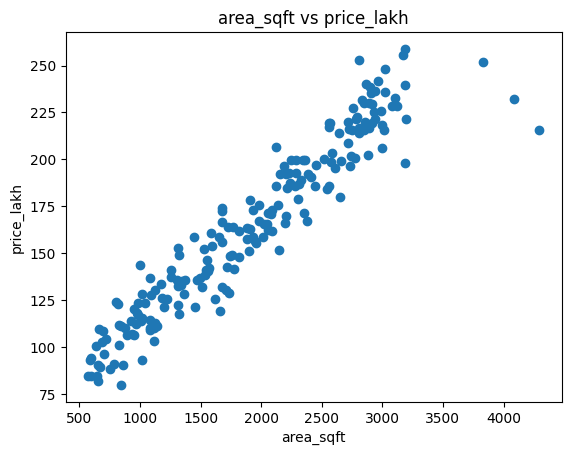

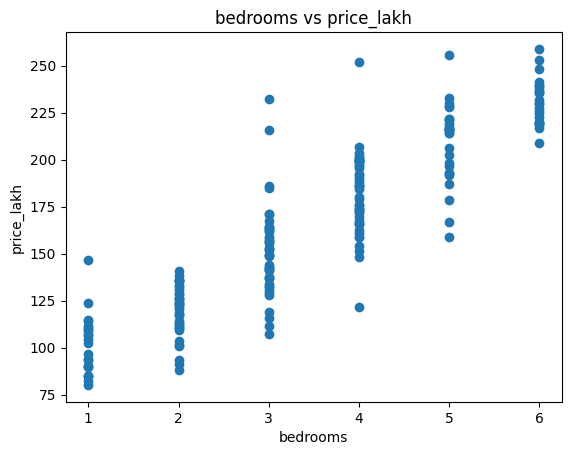

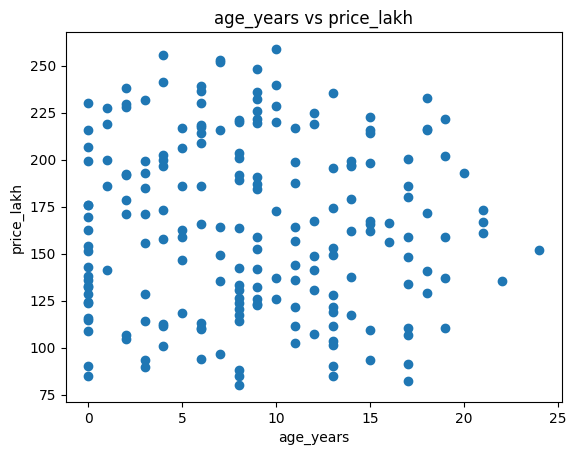

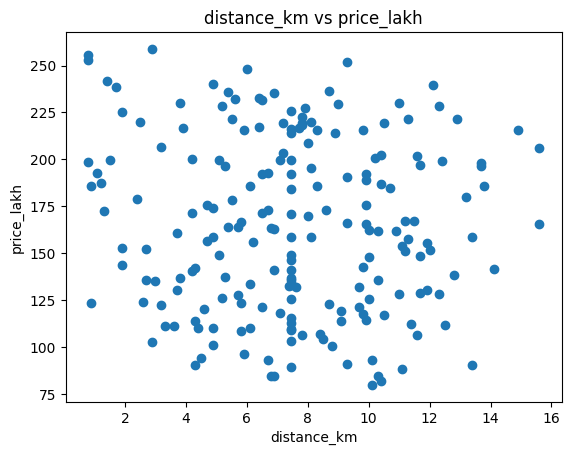

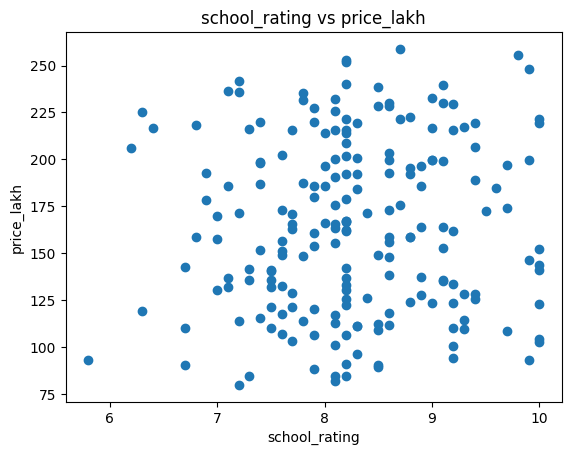

In [ ]:
features = ["area_sqft", "bedrooms", "age_years", "distance_km", "school_rating"]
for col in features:
    plt.figure()
    plt.scatter(df[col], df["price_lakh"])
    plt.title(f"{col} vs price_lakh")
    plt.xlabel(col)
    plt.ylabel("price_lakh")
    plt.show()

In [ ]:
corr = df[features + ["price_lakh"]].corr(numeric_only=True)
print("\n---- CORRELATION ----")
display(corr)


---- CORRELATION ----


,area_sqft,bedrooms,age_years,distance_km,school_rating,price_lakh
area_sqft,1.000000,0.840883,0.038830,0.087489,-0.076540,0.950912
bedrooms,0.840883,1.000000,0.021894,-0.031366,-0.080439,0.907938
age_years,0.038830,0.021894,1.000000,0.024103,-0.022707,-0.031303
distance_km,0.087489,-0.031366,0.024103,1.000000,-0.060634,-0.073129
school_rating,-0.076540,-0.080439,-0.022707,-0.060634,1.000000,0.053259
price_lakh,0.950912,0.907938,-0.031303,-0.073129,0.053259,1.000000


In [ ]:
roll_no=10
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=roll_no)
print(X_train)
print(X_test)
print(Y_train)
print(Y_test)


     area_sqft  bedrooms
190       2780         5
7         2202         5
26        2568         6
138       2241         4
58        1473         2
..         ...       ...
113        755         2
64        1757         3
15        3188         6
125        782         2
9         2287         5

[160 rows x 2 columns]
     area_sqft  bedrooms
59        1200         4
5         1588         4
20        1221         2
198       2315         5
52        3078         5
19         845         1
162       2206         4
55        2353         3
69        2579         4
2         2807         6
98         593         1
10        2126         4
75        1985         4
142       1880         3
124       2850         5
63        2059         4
109        878         1
78        1779         3
111       2994         5
185       2716         6
154       1571         3
130       2658         4
61         696         1
87        3187         6
102       2285         4
121       1676         5
1

In [ ]:
model= LinearRegression()
model.fit(X_train,Y_train)
print("intercept(00):", model.intercept_)
coef_table=pd.DataFrame({"Feature": X.columns, "Coefficient (0j)": model.coef_});
display(coef_table)

intercept(00): 57.794057721648954


,Feature,Coefficient (0j)
0,area_sqft,0.035228
1,bedrooms,11.471053


In [ ]:
Y_pred=model.predict(X_test)
print(Y_pred)

[145.95230409 159.62090854 123.74999371 196.70298071 223.58222091
  99.0330766  181.39203626 175.09955248 194.53221528 225.5063878
  90.15552938 178.5737673  173.60656826 158.43653725 215.55015438
 176.21346704 100.19561255 154.87847269 220.62303851 222.30060686
 147.5509734  197.31525588  93.78405066 238.89316536 184.17507686
 174.19205739 187.8388265  145.43727168 109.51773546 167.54728999
 182.46228014  92.33968782 116.5281795  163.1219094  101.8161172
 152.44771572 167.80728155 102.80251134 118.88847975 182.87162746]


In [ ]:
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mean_squared_error(Y_test,Y_pred))
r2=r2_score(Y_test,Y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 10.696349311779642
RMSE: 13.278154050120072
R2: 0.9146637295164508
